In [1]:
import pymupdf

In [3]:
from pathlib import Path

In [4]:
pdfs = sorted(Path("content").glob("*/*.pdf"))

In [7]:
len(pdfs)

2133

In [8]:
pdfs[0]

PosixPath('content/1508049984/1508049984.pdf')

In [24]:
!rm test.pdf

In [25]:
Path(f"test.pdf").symlink_to(pdfs[1])

In [26]:
doc = pymupdf.open("test.pdf")

In [11]:
from io import BytesIO

In [12]:
from PIL import Image


In [13]:
def get_figure_and_text(fig1,page):
    above_bbox = (fig1[0],0,fig1[2],fig1[1])
    pix = page.get_pixmap()
    page_im=Image.open(BytesIO(pix.tobytes()))
    figure_text_image = page_im.crop(fig1[:4])
    figure_image = page_im.crop(above_bbox)
    return dict(figure_text_image=figure_text_image,figure_image = figure_image)

def get_figure_sections_on_page(page):
    figure_blocks = [b for b in page.get_text("blocks")  if "FIG" in b[4]]
    return figure_blocks

In [14]:
def run_figure_extraction(doc):
    results = []
    for page in doc:
        
        figure_blocks = get_figure_sections_on_page(page)
        for fb in figure_blocks:
            fig_and_text = get_figure_and_text(fb,page)
            results.append(dict(figure_blocks = figure_blocks, fig_and_text = fig_and_text))
    return results

In [16]:
results = run_figure_extraction(doc)

In [17]:
results

[]

In [68]:
long_doc = pymupdf.open("3213425384.pdf")

In [69]:
run_figure_extraction(long_doc)

[]

In [75]:
page = long_doc[29]

In [78]:
[b for b in page.get_text("blocks") if "Figure" in b[4] ]

[(222.1230010986328,
  59.953643798828125,
  373.1770324707031,
  71.9207992553711,
  'Figure 2: Data for Product I.\n',
  0,
  0),
 (216.04299926757812,
  438.1706237792969,
  379.24346923828125,
  450.1377868652344,
  'Figure 3: Results for Product I.\n',
  2,
  0)]

In [77]:
page.get_text("blocks")

[(222.1230010986328,
  59.953643798828125,
  373.1770324707031,
  71.9207992553711,
  'Figure 2: Data for Product I.\n',
  0,
  0),
 (51.02400207519531,
  83.2164535522461,
  544.0941772460938,
  129.04458618164062,
  'Panel (a) reports the daily sales divided by the number of stores aggregated for all cities as well as for the treatment and control\ngroups. The plot also indicates the date of the intervention. Panels (b) and (c) display the distribution of the average sales per store\nover time across municipalities in the treatment and control groups, respectively. Panels (d) and (e) present fan plots of sales across\nmunicipalities in the treatment and control groups for each given time point. The black curves represent the cross-sectional mean over\ntime and the vertical green line indicates the date of intervention.\n',
  1,
  0),
 (216.04299926757812,
  438.1706237792969,
  379.24346923828125,
  450.1377868652344,
  'Figure 3: Results for Product I.\n',
  2,
  0),
 (51.0240020751

In [20]:

is_first =True
# process each block 
for i,block in enumerate(page.get_text("blocks")):
    # see if block is a figure block
    if 
    # sam

SyntaxError: invalid syntax (2939596945.py, line 9)

In [48]:
# biggest issue in this article is determining whether the figure is above or below the text we identify is a figure section
# assumption #1, a text and it's image are always on the same page
# assumption an image will represent a break in the amount of space on a page registered by blocks 
# the same rule will apply for all figures on a page, perhaps even throughout a document
def is_figure_block(b):
    b_text = b[4]
    return "FIG." in b_text or "Figure" in b_text
results = []
fig_pages = []
for page in doc:
    blocks = page.get_text("blocks")
    for b in blocks:
        res = is_figure_block(b)
        if res:
            fig_pages+=[page]
            results.append(get_figure_and_text(b,page))
        

In [49]:
results

[{'figure_text_image': <PIL.Image.Image image mode=RGB size=472x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=472x321>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=472x14>,
  'figure_image': <PIL.Image.Image image mode=RGB size=472x155>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=471x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=471x406>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=472x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=472x457>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=472x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=472x429>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=469x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=469x319>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB size=42x16>,
  'figure_image': <PIL.Image.Image image mode=RGB size=42x71>},
 {'figure_text_image': <PIL.Image.Image image mode=RGB siz

In [51]:
len(results)

12

In [52]:
results[0]["figure_text_image"]

In [34]:
fig_pages

[page 1 of test.pdf,
 page 11 of test.pdf,
 page 19 of test.pdf,
 page 27 of test.pdf,
 page 28 of test.pdf,
 page 29 of test.pdf,
 page 39 of test.pdf,
 page 39 of test.pdf,
 page 39 of test.pdf,
 page 40 of test.pdf,
 page 41 of test.pdf,
 page 42 of test.pdf]

In [ ]:
p=fig_pages[-1]

blocks = p.get_text("blocks")

fig_blocks = [b for b in blocks if "Figure" in b[4]]
fig_blocks

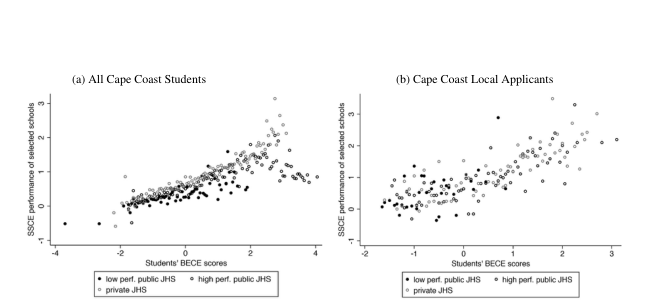

In [46]:
get_figure_and_text(fig_blocks[0],p)["figure_image"]

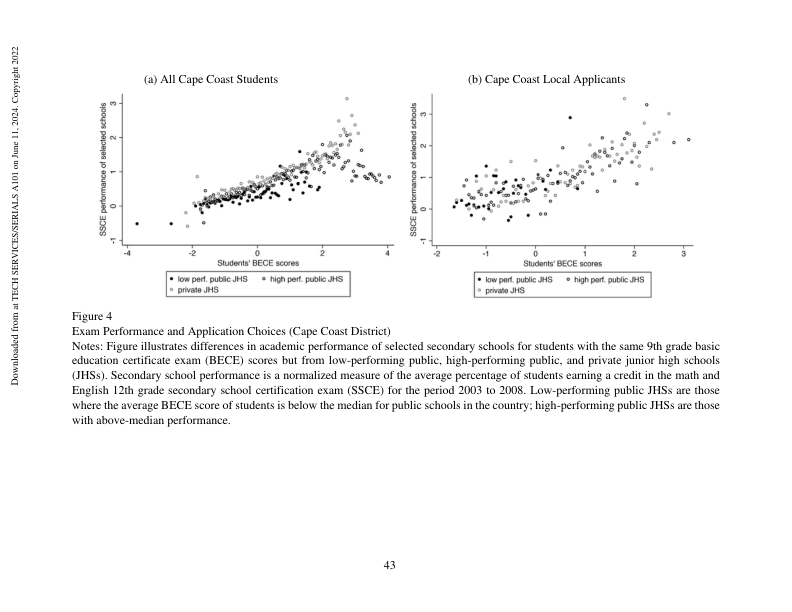

In [38]:
pixmap = p.get_pixmap()

Image.open(BytesIO(pixmap.tobytes()))

In [50]:
p.get_text("blocks")

[(72.0, 35.9976806640625, 74.642578125, 50.0660400390625, ' \n', 0, 0),
 (383.80999755859375,
  555.9000244140625,
  398.80999755859375,
  571.9080200195312,
  '43 \n',
  1,
  0),
 (72.0,
  70.54399108886719,
  628.4199829101562,
  86.55199432373047,
  ' \n \n(a) All Cape Coast Students  \n \n \n \n \n(b) Cape Coast Local Applicants \n',
  2,
  0),
 (701.5, 294.85400390625, 704.5, 310.86199951171875, ' \n', 3, 0),
 (72.0,
  307.0940246582031,
  723.0220947265625,
  427.4020080566406,
  'Figure 4 \nExam Performance and Application Choices (Cape Coast District) \nNotes: Figure illustrates differences in academic performance of selected secondary schools for students with the same 9th grade basic \neducation certificate exam (BECE) scores but from low-performing public, high-performing public, and private junior high schools \n(JHSs). Secondary school performance is a normalized measure of the average percentage of students earning a credit in the math and \nEnglish 12th grade secondary s

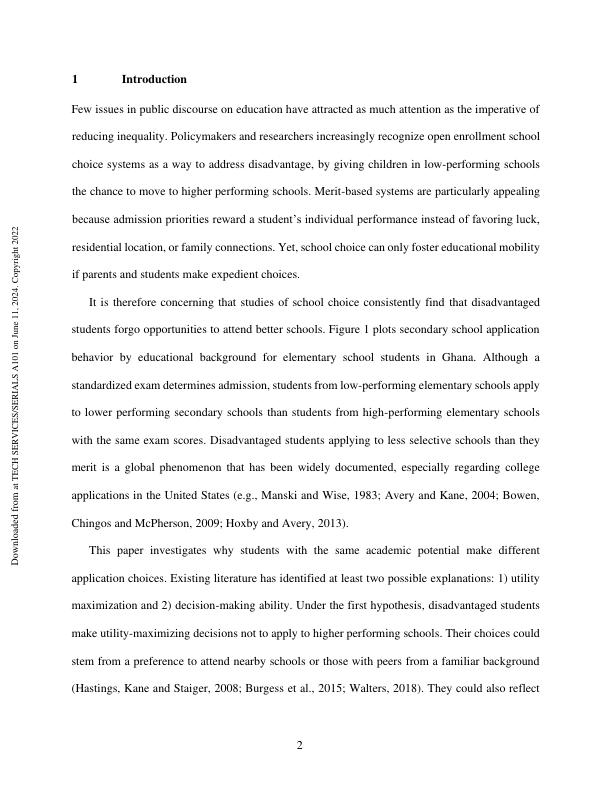

In [57]:
page1 = fig_pages[0]

Image.open(BytesIO(page1.get_pixmap().tobytes()))

In [ ]:
# the idea is that we can identify a threshold that the images are probably bigger than and if we don't find a gap like that above or below the mention then it's not valid

In [54]:
blocks = page1.get_text("blocks")

for b in blocks:
    if "Figure" in b[4]:
        # initalize a look back through the blocks to estimate the deltas "amount of empty space" above or below the mention
        

[(72.02400207519531,
  35.9976806640625,
  74.66658020019531,
  50.0660400390625,
  ' \n',
  0,
  0),
 (299.80999755859375,
  737.3976440429688,
  302.45257568359375,
  751.4660034179688,
  ' \n',
  1,
  0),
 (209.69000244140625,
  70.65199279785156,
  426.42999267578125,
  87.2719955444336,
  'School Choice and Educational Mobility:  \n',
  2,
  0),
 (174.6199951171875,
  85.53199768066406,
  458.5,
  102.1520004272461,
  'Lessons from Secondary School Applications in Ghana \n',
  3,
  0),
 (315.04998779296875,
  100.30400085449219,
  318.04998779296875,
  116.31200408935547,
  ' \n',
  4,
  0),
 (258.7699890136719,
  114.79389190673828,
  348.7900085449219,
  131.19200134277344,
  'Kehinde F. Ajayi* \n',
  5,
  0),
 (299.80999755859375,
  142.77198791503906,
  302.80999755859375,
  159.39198303222656,
  ' \n',
  6,
  0),
 (277.489990234375,
  167.7320098876953,
  325.1499938964844,
  184.3520050048828,
  'Abstract \n',
  7,
  0),
 (116.9000015258789,
  192.46397399902344,
  501.21197